# Random Forest для поиска экзопланет

Требуется построить модель для набора данных с характеристиками космических объектов. Объекты описываются признаками, полученными в ходе наблюдения через телескоп Kepler. Среди них — радиус, период обращения вокруг звезды, её температура, светимость, масса и другие.

In [27]:
# Установка зависимостей
# Установка зависимостей
!pip install -q \
  scikit-learn==1.6.1 \
  numpy \
  pandas \
  optuna \
  matplotlib \
  seaborn

In [18]:
import pandas as pd

df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s15t3_exoplanet_regression.csv')

print(f"Размер выборки: {df.shape}")

print("\nПервые строки выборки:")
print(df.head())

Размер выборки: (19761, 17)

Первые строки выборки:
     pc1       pc2       pc3   ra  dec   j_mag   h_mag   k_mag  kep_mag  \
0  0.036 -0.469118 -0.051703  317  -63  14.254  13.900  13.826   15.436   
1  0.029 -0.453369  0.408759  194   31  14.326  13.911  13.809   15.597   
2  0.040 -0.455314  0.015327  192   79  14.366  14.064  13.952   15.509   
3 -0.048  0.062012  0.022569   94   61  14.528  14.113  14.132   15.714   
4  0.012 -0.189558  0.008973  340  -71  14.528  14.113  14.132   15.714   

   orbital_period  star_teff  star_logg  star_radius  star_mass  lc_time0  \
0           35677     5853.0      4.544        0.868      0.961   0.00235   
1           47532     5805.0      4.564        0.791      0.836   0.93347   
2           18872     6031.0      4.438        1.046      1.095   0.91598   
3           11524     6046.0      4.486        0.972      1.053   0.63158   
4            2194     6046.0      4.486        0.972      1.053   0.47332   

       label  planet_radius  
0   

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop('planet_radius', axis=1)
y = df['planet_radius']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=616)

print(f'Размер обучающей выборки: {len(X_train)}')
print(f'Размер тестовой выборки: {len(X_test)}')

Размер обучающей выборки: 15808
Размер тестовой выборки: 3953


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("ohe_label", OneHotEncoder(handle_unknown="ignore"), ['label'])
    ],
    remainder="passthrough"
)
print(preprocessor)

ColumnTransformer(remainder='passthrough',
                  transformers=[('ohe_label',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['label'])])


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor

model_tree = DecisionTreeRegressor(random_state=616)

model_bagging = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=616),
    n_estimators=50,
    random_state=616
)

model_rf = RandomForestRegressor(
    n_estimators=50,
    max_features="sqrt",
    random_state=616
)

pipe_tree = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model_tree)
])
print("Пайплайн pipe_tree успешно создан.")

pipe_bagging = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model_bagging)
])
print("Пайплайн pipe_bagging успешно создан.")

pipe_rf = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model_rf)
])
print("Пайплайн pipe_rf успешно создан.")

Пайплайн pipe_tree успешно создан.
Пайплайн pipe_bagging успешно создан.
Пайплайн pipe_rf успешно создан.


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Обучим пайплайны
pipe_tree.fit(X_train, y_train)
pipe_bagging.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

# Предсказания
y_test_pred_tree = pipe_tree.predict(X_test)
y_test_pred_bagging = pipe_bagging.predict(X_test)
y_test_pred_rf = pipe_rf.predict(X_test)

# Метрики
results = {
    "model": ["DecisionTree", "Bagging", "RandomForest"],
    "MAE": [
        mean_absolute_error(y_test, y_test_pred_tree),
        mean_absolute_error(y_test, y_test_pred_bagging),
        mean_absolute_error(y_test, y_test_pred_rf),
    ],
    "MSE": [
        mean_squared_error(y_test, y_test_pred_tree),
        mean_squared_error(y_test, y_test_pred_bagging),
        mean_squared_error(y_test, y_test_pred_rf),
    ],
    "R2": [
        r2_score(y_test, y_test_pred_tree),
        r2_score(y_test, y_test_pred_bagging),
        r2_score(y_test, y_test_pred_rf),
    ],
}

df_metrics = pd.DataFrame(results)
print(df_metrics)

          model       MAE          MSE        R2
0  DecisionTree  9.736248  6215.697013 -0.259404
1       Bagging  9.044490  4962.306743 -0.005446
2  RandomForest  9.146986  3700.050619  0.250308


In [23]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 100),
        "max_depth": trial.suggest_int("max_depth", 10, 50),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "max_samples": trial.suggest_float("max_samples", 0.7, 1.0),
    }

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(**params, random_state=616))
    ])

    scores = cross_val_score(pipeline, X_train, y_train, cv=3, scoring="r2")
    return scores.mean()


sampler = optuna.samplers.TPESampler(seed=616)
study = optuna.create_study(direction="maximize", sampler=sampler)

study.optimize(objective, n_trials=25, show_progress_bar=True)

best_params = study.best_params
best_value = round(study.best_value, 3)

print(f"Лучшие гиперпараметры: {best_params}")
print(f"Лучшее значение r2: {best_value}")

[I 2026-06-12 10:11:37,135] A new study created in memory with name: no-name-546802e4-442b-4b0b-8d5e-f6a3303a741b


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-06-12 10:12:03,733] Trial 0 finished with value: -0.034979875062161124 and parameters: {'n_estimators': 89, 'max_depth': 47, 'max_features': None, 'max_samples': 0.7091895573579126}. Best is trial 0 with value: -0.034979875062161124.
[I 2026-06-12 10:12:10,514] Trial 1 finished with value: -0.12664713616407663 and parameters: {'n_estimators': 94, 'max_depth': 47, 'max_features': 'log2', 'max_samples': 0.7196615291102929}. Best is trial 0 with value: -0.034979875062161124.
[I 2026-06-12 10:12:15,570] Trial 2 finished with value: -0.12304310952953819 and parameters: {'n_estimators': 61, 'max_depth': 32, 'max_features': 'log2', 'max_samples': 0.9437017448486941}. Best is trial 0 with value: -0.034979875062161124.
[I 2026-06-12 10:12:20,473] Trial 3 finished with value: -0.06848660069578667 and parameters: {'n_estimators': 61, 'max_depth': 29, 'max_features': 'log2', 'max_samples': 0.9302084598826005}. Best is trial 0 with value: -0.034979875062161124.
[I 2026-06-12 10:12:28,254] T

In [24]:
best_model = RandomForestRegressor(**best_params, random_state=616)
best_pipeline = pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", best_model)
    ])

best_pipeline.fit(X_train, y_train)
y_test_pred = best_pipeline.predict(X_test)

results = {
    "model": ["Best_RandomForest"],
    "MAE": [mean_absolute_error(y_test, y_test_pred)],
    "MSE": [mean_squared_error(y_test, y_test_pred)],
    "R2": [r2_score(y_test, y_test_pred)],
}
df_metrics = pd.DataFrame(results)
print(df_metrics)

               model       MAE          MSE        R2
0  Best_RandomForest  9.382394  5522.681469 -0.118987


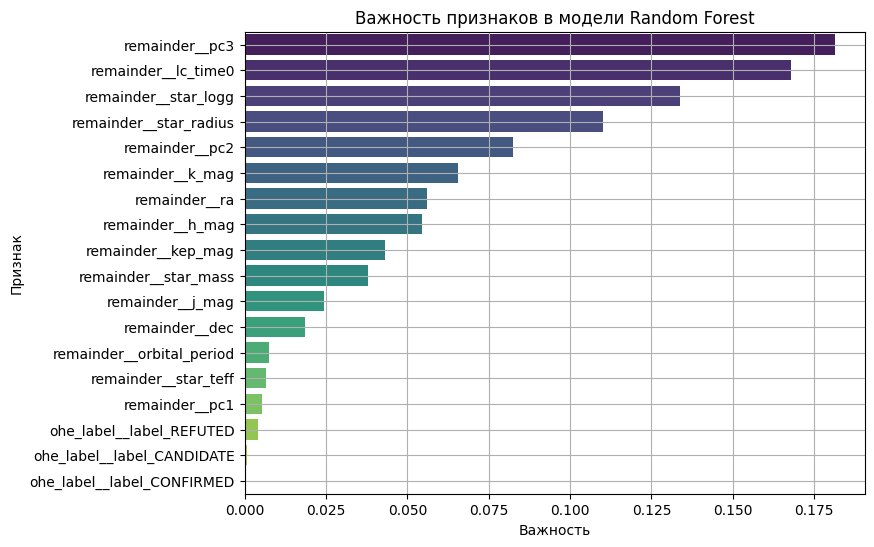

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Получите названия признаков и их важность из best_pipeline
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = best_pipeline.named_steps['model'].feature_importances_

feature_importances = pd.DataFrame({
    'feature': feature_names, # Передайте названия признаков
    'importance': importances # Передайте значения важности признаков
})
# Отсортируем по убыванию важности
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

# Создадим график
plt.figure(figsize=(8, 6))
sns.barplot(
    data=feature_importances, # Передайте датасет с признаками 
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis'
)
plt.title('Важность признаков в модели Random Forest')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.grid()
plt.show()

Полученный график позволяет сделать следующие выводы:

Достаточно большую важность для модели показали инфракрасные звёздные величины: h_mag, k_mag и j_mag. Это говорит о том, что инфракрасная яркость звезды тесно связана с определением радиуса планеты — возможно, это связано с влиянием яркости на достоверность наблюдений.

Признаки, характеризующие звезду, такие как star_logg (поверхностная гравитация) и star_radius, также влияют на радиус объекта.

Прямое восхождение ( ra ) и склонение ( dec ) имеют крайне низкую важность (по 0.02 и 0.014). Это ожидаемо — координаты положения на небе не влияют на физические параметры космического объекта.

Главные компоненты ( pc1, pc2, pc3 ) в сумме дают заметный вклад (около 0.17). Это значит, что между целевой переменной и характеристиками, которые зашифрованы в этих компонентах, есть определённая связь.

Орбитальный период и эффективная температура звезды почти не важны. Параметры orbital_period и star_teff дают скромный вклад в предсказание.